In [250]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import joypy
import scipy

In [3]:
chromosomes = ['OX359245.1',
       'OX359246.1', 'OX359247.1', 'OX359248.1', 'OX359249.1',
       'OX359250.1']

In [76]:
orthodiver_tsv = 'allacma_fusca.sminthurus_viridis.orthodiver_agg.tsv'
deseq_tsv = 'v_4/allacma_fusca.DEseq2_results_filtered.tsv'
orthogroup_file = 'SC_orthogroups.txt'
cds_bed = 'allacma_fusca.cds.bed'

orthodiver_df = pd.read_csv(orthodiver_tsv, sep='\t')
orthodiver_df.rename(columns={'Orthogroup':'orthogroup'}, inplace=True)
orthodiver_df['dnds'] = orthodiver_df['0d_dxy']/orthodiver_df['4d_dxy']

deseq_df = pd.read_csv(deseq_tsv, sep='\t')
deseq_df['bias'] = np.where(deseq_df['log2FoldChange']>0,  'male_biased','female_biased')

orthogroup_df = pd.read_csv(orthogroup_file, sep=' ', names=['orthogroup','afusca','sviridis'])
orthogroup_df['orthogroup'] = orthogroup_df.orthogroup.str.replace(':','')
orthogroup_df['afusca'] = orthogroup_df.afusca.str.replace('allacma_fusca.','')
orthogroup_df['sviridis'] = orthogroup_df.afusca.str.replace('sminthurus_viridis.','')
orthogroup_df['Geneid'] = orthogroup_df.afusca.str.split('.',expand=True)[0]

cds_df = pd.read_csv(cds_bed, sep='\t', header=None)
cds_df = cds_df[[0,3]].rename(columns={0:'chromosome',3:'transcript'})
cds_df['Geneid'] = cds_df['transcript'].str.split('.', expand=True)[0]
cds_df = cds_df[cds_df.chromosome.isin(chromosomes)].reset_index()[['chromosome','Geneid']]
cds_df['type'] = np.where(cds_df.chromosome.isin(['OX359249.1','OX359250.1']), 'X','Autosome')

In [77]:
deseq_df = deseq_df.merge(cds_df[['Geneid','type']], on='Geneid', how='outer')
bias_df = orthodiver_df.merge(orthogroup_df[['orthogroup','Geneid']].merge(deseq_df[['Geneid','bias','type']], on='Geneid'), on='orthogroup', how='outer')
bias_df['bias'] = bias_df.bias.fillna('unbiased')

In [298]:
deseq_df

,Geneid,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,bias,type
0,g1000,NaN,NaN,NaN,NaN,NaN,NaN,unbiased,Autosome
1,g10000,NaN,NaN,NaN,NaN,NaN,NaN,unbiased,Autosome
2,g10001,NaN,NaN,NaN,NaN,NaN,NaN,unbiased,Autosome
3,g10002,NaN,NaN,NaN,NaN,NaN,NaN,unbiased,Autosome
4,g10003,5.877386,1.84275,0.73703,2.500236,0.012411,0.0298,male_biased,Autosome
...,...,...,...,...,...,...,...,...,...
24287,g9995,NaN,NaN,NaN,NaN,NaN,NaN,unbiased,Autosome
24288,g9996,NaN,NaN,NaN,NaN,NaN,NaN,unbiased,Autosome
24289,g9997,NaN,NaN,NaN,NaN,NaN,NaN,unbiased,Autosome
24290,g9998,NaN,NaN,NaN,NaN,NaN,NaN,unbiased,Autosome


In [295]:
deseq_df['bias'] = deseq_df['bias'].fillna('unbiased')
deseq_df[deseq_df['bias']=='male_biased'].groupby('type').count()

,Geneid,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,bias
type,,,,,,,,
Autosome,3844,3844,3844,3844,3844,3844,3844,3844
X,1754,1754,1754,1754,1754,1754,1754,1754


In [296]:
deseq_df[deseq_df['bias']!='male_biased'].groupby('type').count()

,Geneid,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,bias
type,,,,,,,,
Autosome,14698,1794,1794,1794,1794,1794,1794,14698
X,3947,444,444,444,444,444,444,3947


In [297]:
3844 1754
14698 3947

SyntaxError: invalid syntax (2705542102.py, line 1)

In [275]:
deseq_df.groupby(['bias','type']).count()

Geneid  baseMean  log2FoldChange  lfcSE  stat  pvalue  \
bias          type                                                              
female_biased Autosome    1794      1794            1794   1794  1794    1794   
              X            444       444             444    444   444     444   
male_biased   Autosome    3844      3844            3844   3844  3844    3844   
              X           1754      1754            1754   1754  1754    1754   

                        padj  
bias          type            
female_biased Autosome  1794  
              X          444  
male_biased   Autosome  3844  
              X         1754

In [78]:
bias_df[bias_df.bias=='male_biased']

,orthogroup,0d_pi_allacma_fusca,0d_pi_sminthurus_viridis,0d_pi_mean,4d_pi_allacma_fusca,4d_pi_sminthurus_viridis,4d_pi_mean,0d_dxy,4d_dxy,0d_da,4d_da,dnds,alpha,Geneid,bias,type
5,OG0005222,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.038912,0.571429,0.038912,0.571429,0.068097,1.000000,g238,male_biased,Autosome
6,OG0005223,0.000337,0.0,0.000168,0.007473,0.0,0.003737,0.059172,0.605445,0.059003,0.601709,0.097733,0.538669,g255,male_biased,Autosome
7,OG0005224,0.000841,0.0,0.000420,0.000608,0.0,0.000304,0.078907,0.668375,0.078487,0.668071,0.118058,-10.705355,g257,male_biased,Autosome
9,OG0005226,0.000305,0.0,0.000153,0.001508,0.0,0.000754,0.019902,0.571212,0.019750,0.570457,0.034842,-4.808422,g272,male_biased,Autosome
10,OG0005227,0.000375,0.0,0.000188,0.000000,0.0,0.000000,0.049737,0.722361,0.049550,0.722361,0.068854,1.000000,g278,male_biased,Autosome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12250,OG0017716,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.212500,0.000000,0.212500,0.000000,1.000000,g18624,male_biased,Autosome
12255,OG0017721,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.023952,0.540541,0.023952,0.540541,0.044311,1.000000,g18633,male_biased,Autosome
12278,OG0017744,0.000997,0.0,0.000499,0.000000,0.0,0.000000,0.039173,0.451613,0.038675,0.451613,0.086741,1.000000,g18664,male_biased,Autosome
12291,OG0017759,0.000518,0.0,0.000259,0.017361,0.0,0.008681,0.044056,0.579119,0.043797,0.570438,0.076074,0.608096,g99,male_biased,NaN


In [79]:
orthodiver_df.alpha.describe()

count    12255.000000
mean         0.421119
std         16.346917
min      -1788.234646
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: alpha, dtype: float64

In [80]:
bias_df[bias_df.bias=='female_biased']

,orthogroup,0d_pi_allacma_fusca,0d_pi_sminthurus_viridis,0d_pi_mean,4d_pi_allacma_fusca,4d_pi_sminthurus_viridis,4d_pi_mean,0d_dxy,4d_dxy,0d_da,4d_da,dnds,alpha,Geneid,bias,type
36,OG0005253,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.037433,0.500000,0.037433,0.500000,0.074866,1.0,g370,female_biased,Autosome
61,OG0005284,0.000000,0.0,0.000000,0.024244,0.0,0.012122,0.032053,0.427180,0.032053,0.415058,0.075034,1.0,g498,female_biased,Autosome
66,OG0005289,0.000000,0.0,0.000000,0.001083,0.0,0.000542,0.016614,0.454318,0.016614,0.453776,0.036569,1.0,g547,female_biased,Autosome
69,OG0005292,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.027126,0.555556,0.027126,0.555556,0.048827,1.0,g564,female_biased,Autosome
80,OG0005305,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.040998,0.588663,0.040998,0.588663,0.069645,1.0,g618,female_biased,Autosome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12216,OG0017681,0.000093,0.0,0.000046,0.000000,0.0,0.000000,0.032376,0.353913,0.032330,0.353913,0.091481,1.0,g18556,female_biased,Autosome
12220,OG0017685,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.040350,0.398864,0.040350,0.398864,0.101162,1.0,g18565,female_biased,Autosome
12234,OG0017700,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.034481,0.489140,0.034481,0.489140,0.070492,1.0,g18595,female_biased,Autosome
12249,OG0017715,0.000000,0.0,0.000000,0.006000,0.0,0.003000,0.021661,0.526000,0.021661,0.523000,0.041180,1.0,g18623,female_biased,Autosome


In [81]:
bias_df[bias_df.bias=='unbiased']

,orthogroup,0d_pi_allacma_fusca,0d_pi_sminthurus_viridis,0d_pi_mean,4d_pi_allacma_fusca,4d_pi_sminthurus_viridis,4d_pi_mean,0d_dxy,4d_dxy,0d_da,4d_da,dnds,alpha,Geneid,bias,type
0,OG0005214,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.011521,0.312500,0.011521,0.312500,0.036866,1.000000,g157,unbiased,Autosome
1,OG0005215,0.000876,0.0,0.000438,0.010309,0.0,0.005155,0.017429,0.465636,0.016990,0.460481,0.037430,-1.271434,g159,unbiased,Autosome
2,OG0005217,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.016698,0.479452,0.016698,0.479452,0.034826,1.000000,g171,unbiased,Autosome
3,OG0005218,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.037479,0.544379,0.037479,0.544379,0.068847,1.000000,g172,unbiased,Autosome
4,OG0005221,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.048611,0.600000,0.048611,0.600000,0.081019,1.000000,g236,unbiased,Autosome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12288,OG0017754,0.000070,0.0,0.000035,0.000284,0.0,0.000142,0.027743,0.678026,0.027708,0.677884,0.040917,-4.997347,NaN,unbiased,NaN
12289,OG0017755,0.000215,0.0,0.000108,0.001990,0.0,0.000995,0.031781,0.509816,0.031674,0.508821,0.062339,-0.735429,NaN,unbiased,NaN
12290,OG0017756,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.010223,0.185484,0.010223,0.185484,0.055116,1.000000,NaN,unbiased,NaN
12292,OG0017760,0.000000,0.0,0.000000,0.001174,0.0,0.000587,0.092240,0.411337,0.092240,0.410750,0.224245,1.000000,NaN,unbiased,NaN


In [82]:
bias_df = bias_df[(bias_df['4d_dxy']>0) & (bias_df['4d_pi_allacma_fusca'] > 0)]

In [162]:
bias_df['pnps'] = (bias_df['0d_pi_allacma_fusca'] / bias_df['4d_pi_allacma_fusca'])

In [163]:
bias_df['a'] = 1 - ( bias_df['pnps'] / bias_df['dnds'])

In [168]:
bias_df[bias_df['pnps']>0]['a'].describe()

count    1686.000000
mean       -3.207705
std        43.909748
min     -1788.234646
25%        -2.048815
50%        -0.520395
75%         0.238841
max         0.966168
Name: a, dtype: float64

In [180]:
bias_df['0d_pi_allacma_fusca'].describe()

count    4630.000000
mean        0.000328
std         0.001149
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000198
max         0.025264
Name: 0d_pi_allacma_fusca, dtype: float64

In [257]:
for stat in ['4d_dxy','dnds','alpha']:
    print('--')
    for bias in ['female_biased','male_biased','unbiased']:
        for linkage in ['Autosome','X']:
            mean = bias_df[(bias_df.bias==bias) & (bias_df.type==linkage)][stat].mean()
            print(f'Mean {stat} in {bias} genes on {linkage} chromosomes = {mean:.2}')
        A = bias_df[(bias_df.bias==bias) & (bias_df.type=='Autosome')][stat]
        X = bias_df[(bias_df.bias==bias) & (bias_df.type=='X')][stat]
        print(f'MWU p = {scipy.stats.mannwhitneyu(A, X).pvalue}')
        print('-')

--
Mean 4d_dxy in female_biased genes on Autosome chromosomes = 0.49
Mean 4d_dxy in female_biased genes on X chromosomes = 0.4
MWU p = 9.526281808908038e-08
-
Mean 4d_dxy in male_biased genes on Autosome chromosomes = 0.52
Mean 4d_dxy in male_biased genes on X chromosomes = 0.49
MWU p = 0.006298670664523922
-
Mean 4d_dxy in unbiased genes on Autosome chromosomes = 0.49
Mean 4d_dxy in unbiased genes on X chromosomes = 0.41
MWU p = 2.4827902252292636e-47
-
--
Mean dnds in female_biased genes on Autosome chromosomes = 0.081
Mean dnds in female_biased genes on X chromosomes = 0.071
MWU p = 0.11930026585043173
-
Mean dnds in male_biased genes on Autosome chromosomes = 0.093
Mean dnds in male_biased genes on X chromosomes = 0.081
MWU p = 0.006089936736186039
-
Mean dnds in unbiased genes on Autosome chromosomes = 0.07
Mean dnds in unbiased genes on X chromosomes = 0.056
MWU p = 8.279578970339332e-10
-
--
Mean alpha in female_biased genes on Autosome chromosomes = 0.077
Mean alpha in female_b

In [267]:
UB = bias_df[(bias_df.bias=='male_biased') & (bias_df.type=='X')]['alpha']
MB = bias_df[(bias_df.bias=='female_biased') & (bias_df.type=='X')]['alpha']
print(UB.mean())
print(MB.mean())
print(f'MWU p = {scipy.stats.mannwhitneyu(UB, MB).pvalue}')

0.3485115204353226
0.4814715533709511
MWU p = 0.9960147378694155


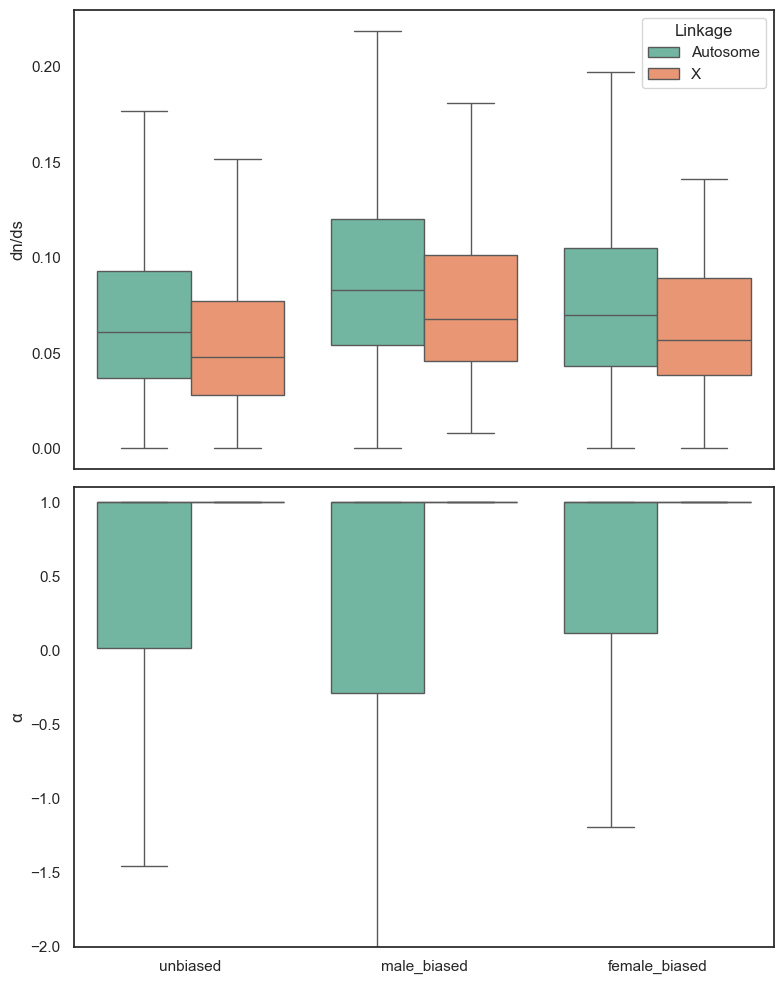

In [85]:
stats_to_plot = ['dnds', 'alpha']
fig, axs = plt.subplots(len(stats_to_plot), 1, figsize=(8, 10), sharex=True)

for i, stat in enumerate(stats_to_plot):
    ax = axs[i]
    sns.boxplot(
        data=bias_df,
        x='bias',    # bias categories on x-axis
        y=stat,      # stat on y-axis
        hue='type',  # linkage (A vs X)
        palette='Set2',
        ax=ax,
        showfliers=False
    )
    #ax.set_title(stat)
    ax.set_xlabel('')  # optional, keep clean
    #ax.set_ylabel(stat)
    ax.legend(title='Linkage')

plt.tight_layout()

axs[0].set_ylabel('dn/ds')

axs[1].set_ylabel('α')
axs[1].legend_.remove()
axs[1].set_ylim([-2,1.1])


plt.show()



In [157]:
bias_df['alpha_clip'].describe()

count    4630.000000
mean       -0.532222
std        26.569431
min     -1788.234646
25%         0.069906
50%         1.000000
75%         1.000000
max         1.000000
Name: alpha, dtype: float64

<Figure size 1000x600 with 0 Axes>

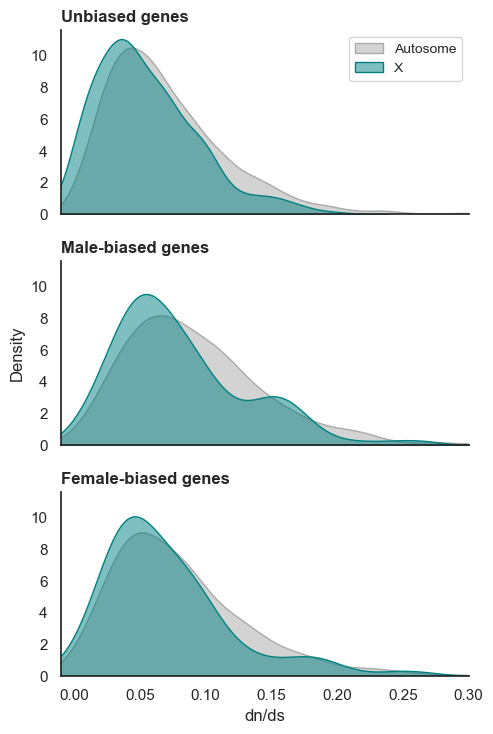

In [170]:
sns.set(style="white")

plt.figure(figsize=(10,6))
g = sns.FacetGrid(bias_df,#[bias_df['pnps']>0], 
                  row='bias', 
                  hue='type', 
                  sharex=True, 
                  sharey=True,
                  height=2.5, 
                  aspect=2,
                  palette={'Autosome': 'darkgray', 'X': 'teal'}
                 )
g.map(sns.kdeplot, 'dnds', fill=True, alpha=0.5)
g.add_legend(title='Linkage')
g.set(xlim=(-0.01, 0.3))

new_titles = {
    'female_biased': 'Female-biased genes',
    'male_biased': 'Male-biased genes',
    'unbiased': 'Unbiased genes'
}

g.set_titles('')
for ax, label in zip(g.axes.flat, bias_df['bias'].unique()):
    ax.set_title(new_titles[label], loc='left', fontsize=12, weight='bold')

g.set_axis_labels('dn/ds', 'Density')  # x-label, y-label

axes = g.axes.flatten()  # get all subplot axes
for i, ax in enumerate(axes):
    if i == 1:  # middle subplot
        ax.set_ylabel('Density', fontsize=12)
    else:
        ax.set_ylabel('') 
        
handles, labels = g.axes[0,0].get_legend_handles_labels() 
g._legend.remove()
g.axes[0,0].legend(handles, labels, loc='upper right', fontsize=10, frameon=True)

plt.savefig("dnds_kde.png", dpi=300, bbox_inches='tight')
plt.savefig("dnds_kde.pdf", bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

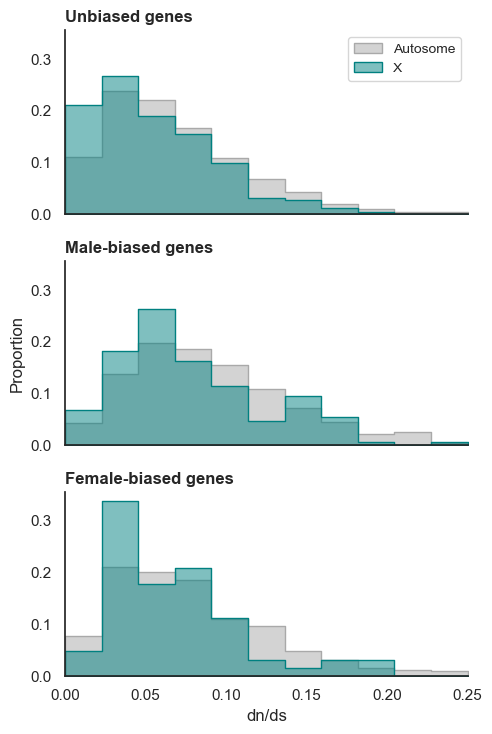

In [249]:
sns.set(style="white")

plt.figure(figsize=(10,6))
g = sns.FacetGrid(bias_df,#[bias_df['pnps']>0], 
                  row='bias', 
                  hue='type', 
                  sharex=True, 
                  sharey=True,
                  height=2.5, 
                  aspect=2,
                  palette={'Autosome': 'darkgray', 'X': 'teal'}
                 )
g.map(sns.histplot, 'dnds',    
      bins=np.linspace(0, 0.25, 12),
    stat='proportion',
    element='step',
    fill=True,
    alpha=0.5
)
g.add_legend(title='Linkage')
g.set(xlim=(0, 0.25))

new_titles = {
    'female_biased': 'Female-biased genes',
    'male_biased': 'Male-biased genes',
    'unbiased': 'Unbiased genes'
}

g.set_titles('')
for ax, label in zip(g.axes.flat, bias_df['bias'].unique()):
    ax.set_title(new_titles[label], loc='left', fontsize=12, weight='bold')

g.set_axis_labels('dn/ds', 'Density')  # x-label, y-label

axes = g.axes.flatten()  # get all subplot axes
for i, ax in enumerate(axes):
    if i == 1:  # middle subplot
        ax.set_ylabel('Proportion', fontsize=12)
    else:
        ax.set_ylabel('') 
        
handles, labels = g.axes[0,0].get_legend_handles_labels() 
g._legend.remove()
g.axes[0,0].legend(handles, labels, loc='upper right', fontsize=10, frameon=True)

plt.savefig("dnds_hist.png", dpi=300, bbox_inches='tight')
plt.savefig("dnds_hist.pdf", bbox_inches='tight')
plt.show()

In [225]:
bias_df['alpha_clip'] = bias_df['alpha'].clip(lower=-5, upper=1)

<Figure size 600x600 with 0 Axes>

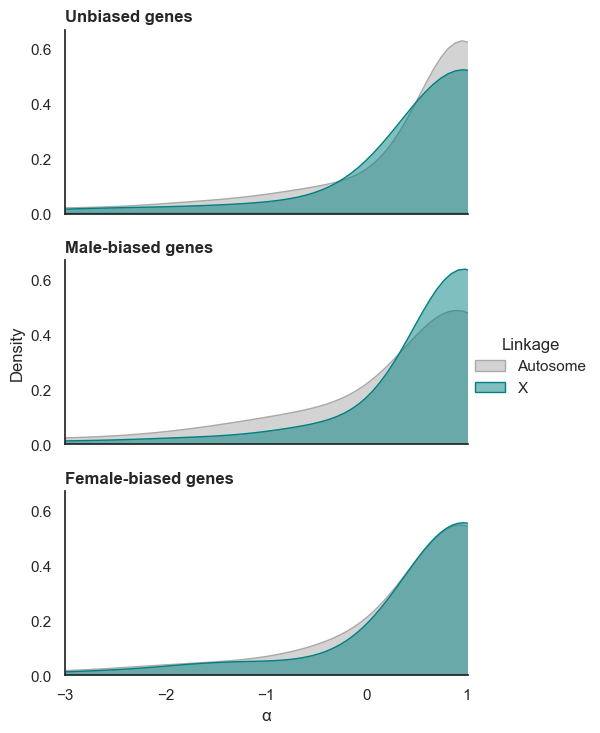

In [221]:
sns.set(style="white")

plt.figure(figsize=(6,6))
g = sns.FacetGrid(bias_df[bias_df['4d_pi_allacma_fusca']>0], 
                  row='bias', 
                  hue='type', 
                  sharex=True, 
                  sharey=True,
                  height=2.5, 
                  aspect=2,
                  palette={'Autosome': 'darkgray', 'X': 'teal'}
                 )
g.map(sns.kdeplot, 'alpha_clip', fill=True, alpha=0.5)
g.add_legend(title='Linkage')
g.set(xlim=(-3, 1.01))

new_titles = {
    'female_biased': 'Female-biased genes',
    'male_biased': 'Male-biased genes',
    'unbiased': 'Unbiased genes'
}

g.set_titles('')
for ax, label in zip(g.axes.flat, bias_df['bias'].unique()):
    ax.set_title(new_titles[label], loc='left', fontsize=12, weight='bold')

g.set_axis_labels('α', 'Density')  # x-label, y-label

axes = g.axes.flatten()  # get all subplot axes
for i, ax in enumerate(axes):
    if i == 1:  # middle subplot
        ax.set_ylabel('Density', fontsize=12)
    else:
        ax.set_ylabel('') 

plt.savefig("alpha_kde.png", dpi=300, bbox_inches='tight')
plt.savefig("alpha_kde.pdf", bbox_inches='tight')
plt.show()

<Figure size 600x600 with 0 Axes>

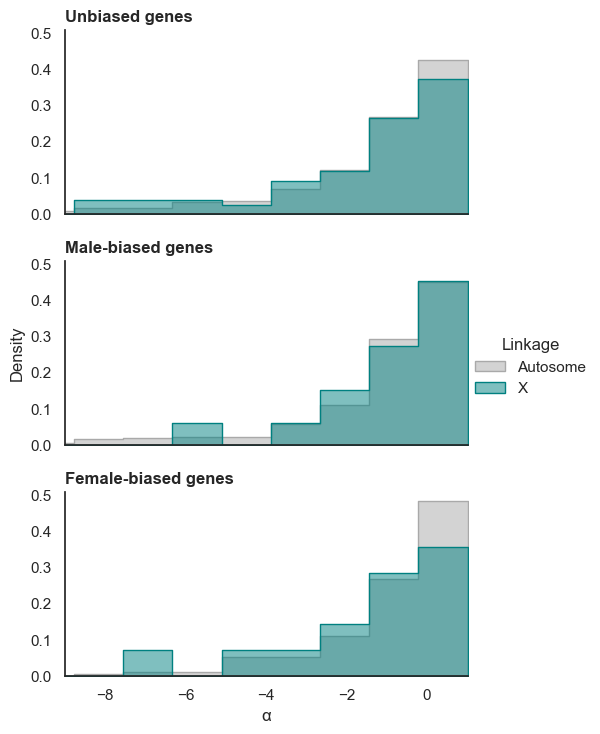

In [245]:
sns.set(style="white")

plt.figure(figsize=(6,6))
g = sns.FacetGrid(bias_df[bias_df['pnps']>0], 
                  row='bias', 
                  hue='type', 
                  sharex=True, 
                  sharey=True,
                  height=2.5, 
                  aspect=2,
                  palette={'Autosome': 'darkgray', 'X': 'teal'}
                 )
g.map(sns.histplot, 'alpha',    
      bins=np.linspace(-10, 1.01, 10),
    stat='proportion',
    element='step',
    fill=True,
    alpha=0.5
)
g.add_legend(title='Linkage')
g.set(xlim=(-9, 1.01))

new_titles = {
    'female_biased': 'Female-biased genes',
    'male_biased': 'Male-biased genes',
    'unbiased': 'Unbiased genes'
}

g.set_titles('')
for ax, label in zip(g.axes.flat, bias_df['bias'].unique()):
    ax.set_title(new_titles[label], loc='left', fontsize=12, weight='bold')

g.set_axis_labels('α', 'Density')  # x-label, y-label

axes = g.axes.flatten()  # get all subplot axes
for i, ax in enumerate(axes):
    if i == 1:  # middle subplot
        ax.set_ylabel('Density', fontsize=12)
    else:
        ax.set_ylabel('') 

plt.savefig("alpha_hist.png", dpi=300, bbox_inches='tight')
plt.savefig("alpha_hist.pdf", bbox_inches='tight')
plt.show()

In [212]:
bias_df

,orthogroup,0d_pi_allacma_fusca,0d_pi_sminthurus_viridis,0d_pi_mean,4d_pi_allacma_fusca,4d_pi_sminthurus_viridis,4d_pi_mean,0d_dxy,4d_dxy,0d_da,4d_da,dnds,alpha,Geneid,bias,type,a,alpha_clip,pnps
1,OG0005215,0.000876,0.0,0.000438,0.010309,0.0,0.005155,0.017429,0.465636,0.016990,0.460481,0.037430,-1.271434,g159,unbiased,Autosome,-1.271434,-1.271434,0.085019
6,OG0005223,0.000337,0.0,0.000168,0.007473,0.0,0.003737,0.059172,0.605445,0.059003,0.601709,0.097733,0.538669,g255,male_biased,Autosome,0.538669,0.538669,0.045087
7,OG0005224,0.000841,0.0,0.000420,0.000608,0.0,0.000304,0.078907,0.668375,0.078487,0.668071,0.118058,-10.705355,g257,male_biased,Autosome,-10.705355,-10.000000,1.381909
9,OG0005226,0.000305,0.0,0.000153,0.001508,0.0,0.000754,0.019902,0.571212,0.019750,0.570457,0.034842,-4.808422,g272,male_biased,Autosome,-4.808422,-4.808422,0.202377
20,OG0005237,0.000000,0.0,0.000000,0.021021,0.0,0.010511,0.045523,0.448354,0.045523,0.437844,0.101535,1.000000,g316,male_biased,Autosome,1.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12288,OG0017754,0.000070,0.0,0.000035,0.000284,0.0,0.000142,0.027743,0.678026,0.027708,0.677884,0.040917,-4.997347,NaN,unbiased,NaN,-4.997347,-4.997347,0.245393
12289,OG0017755,0.000215,0.0,0.000108,0.001990,0.0,0.000995,0.031781,0.509816,0.031674,0.508821,0.062339,-0.735429,NaN,unbiased,NaN,-0.735429,-0.735429,0.108185
12291,OG0017759,0.000518,0.0,0.000259,0.017361,0.0,0.008681,0.044056,0.579119,0.043797,0.570438,0.076074,0.608096,g99,male_biased,NaN,0.608096,0.608096,0.029814
12292,OG0017760,0.000000,0.0,0.000000,0.001174,0.0,0.000587,0.092240,0.411337,0.092240,0.410750,0.224245,1.000000,NaN,unbiased,NaN,1.000000,1.000000,0.000000


In [217]:
bias_df[(bias_df['bias']=='male_biased') & (bias_df['type']=='X') & (bias_df['dnds']>0.12)]['alpha']

1719   -0.174913
1733    1.000000
1963    1.000000
2006    1.000000
2142    1.000000
2160    1.000000
2506    0.167585
2565    0.869233
2639    1.000000
2888    1.000000
2985    1.000000
3021    1.000000
3470    1.000000
5470    1.000000
5555    1.000000
5766    0.139910
5772    1.000000
5783    0.294701
6122    1.000000
6432    1.000000
6471   -0.308477
6500    1.000000
6508    1.000000
6540    1.000000
6551   -0.178763
6597    1.000000
6686    0.407237
6708    1.000000
6712    0.459396
6730    1.000000
6771    0.746950
6829    1.000000
Name: alpha, dtype: float64

In [219]:
bias_df[(bias_df['bias']=='male_biased') & (bias_df['type']=='X') & (bias_df['alpha']==1)]['dnds'].describe()

count    116.000000
mean       0.076528
std        0.047314
min        0.007957
25%        0.043259
50%        0.064226
75%        0.097826
max        0.263323
Name: dnds, dtype: float64